#Importing Required Libraries

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.keras.utils.set_random_seed(SEED)
except:
    pass

try:
    tf.config.experimental.enable_op_determinism()
except:
    pass

In [2]:
import cv2
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

from tensorflow.keras.utils import (
    to_categorical,
    plot_model
)

from tensorflow.keras.models import (
    Sequential,
    Model
)

from tensorflow.keras.layers import (

    Conv2D,
    MaxPooling2D,
    Flatten,

    Dense,
    Dropout,

    BatchNormalization,

    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)
from tensorflow.keras.callbacks import (
    EarlyStopping
)
from tensorflow.keras.applications import VGG16
print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


#Downloading data

In [3]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [4]:
for root, dirs, files in os.walk(path):

    print(root)

    if len(files)>0:
        break

/kaggle/input/gtsrb-german-traffic-sign


#Loading data set

In [5]:
IMG_SIZE = 32
NUM_CLASSES = 43

images = []
labels = []

dataset = os.path.join(path, "Train")

for label in range(NUM_CLASSES):

    folder = os.path.join(dataset, str(label))

    for file in os.listdir(folder):

        try:

            img = cv2.imread(
                os.path.join(folder, file)
            )

            if img is None:
                continue

            img = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            images.append(img)
            labels.append(label)

        except:
            pass

X = np.array(images)
y = np.array(labels)

print(X.shape)

(39209, 32, 32, 3)


In [6]:
print("Total Images :", len(X))
print("Total Classes :", len(np.unique(y)))

class_counts = pd.Series(y).value_counts()

print(class_counts)

Total Images : 39209
Total Classes : 43
2     2250
1     2220
13    2160
12    2100
38    2070
10    2010
4     1980
5     1860
25    1500
9     1470
7     1440
3     1410
8     1410
11    1320
18    1200
35    1200
17    1110
14     780
31     780
33     689
15     630
26     600
28     540
23     510
30     450
34     420
6      420
16     420
22     390
36     390
40     360
20     360
21     330
39     300
29     270
24     270
42     240
32     240
27     240
41     240
0      210
19     210
37     210
Name: count, dtype: int64


#Sample images

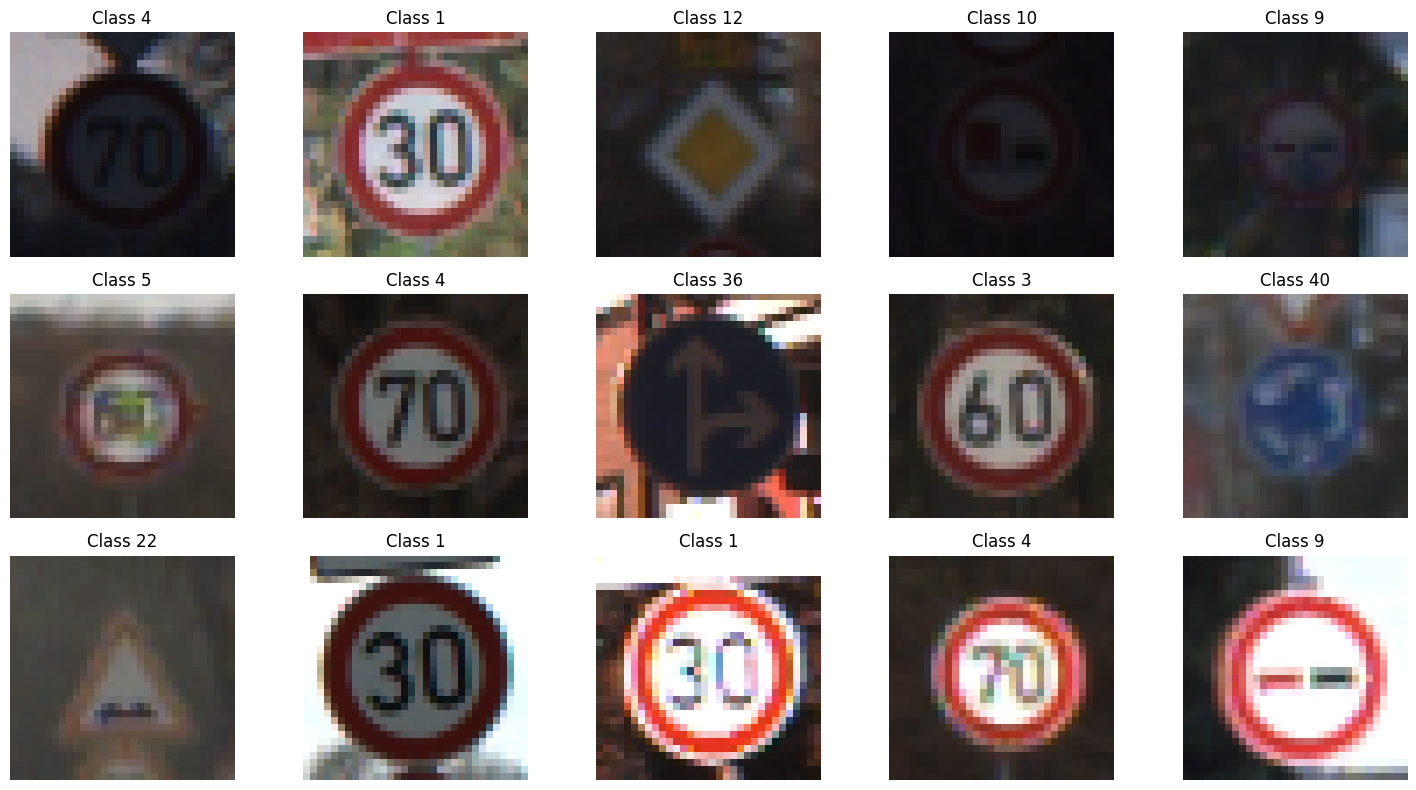

In [7]:
plt.figure(figsize=(15,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    idx = random.randint(0,len(X)-1)

    plt.imshow(X[idx])
    plt.title(f"Class {y[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Class distribution

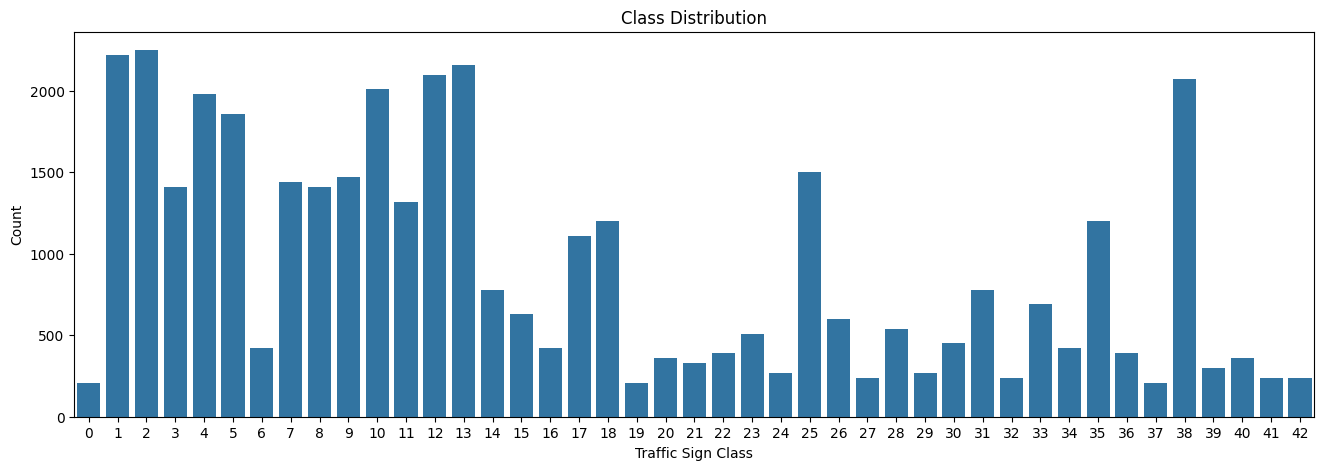

In [8]:
plt.figure(figsize=(16,5))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Traffic Sign Class")
plt.ylabel("Count")

plt.show()

#Distributions

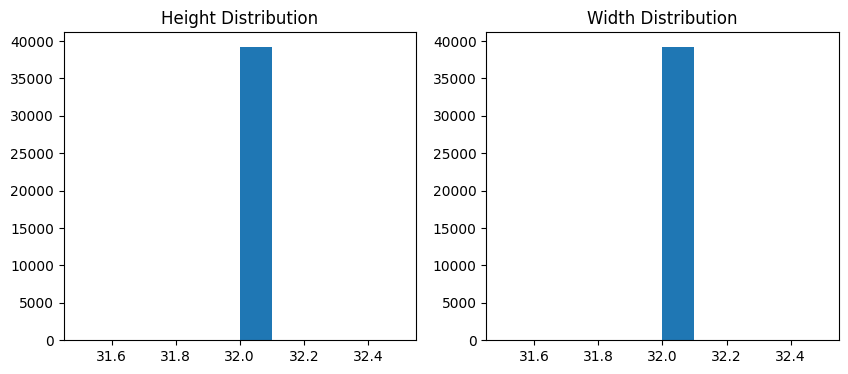

In [9]:
heights = [img.shape[0] for img in X]
widths = [img.shape[1] for img in X]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(heights)

plt.title("Height Distribution")

plt.subplot(1,2,2)
plt.hist(widths)

plt.title("Width Distribution")

plt.show()

#Train test split

In [10]:
X = X.astype("float32") / 255.0

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(27446, 32, 32, 3)
(5881, 32, 32, 3)
(5882, 32, 32, 3)


In [12]:
X_train_small = X_train
y_train_small = y_train

In [13]:
num_classes = 43

y_train_cat = to_categorical(
    y_train_small,
    num_classes
)

y_val_cat = to_categorical(
    y_val,
    num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes
)

#Data Augmentation

In [14]:
datagen = ImageDataGenerator(

    rotation_range=10,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1
)

datagen.fit(X_train_small)

#CNN Model

In [15]:
cnn_model = Sequential([

    Conv2D(
        16,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(),

    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        43,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Training

In [16]:
early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(

    datagen.flow(
        X_train_small,
        y_train_cat,
        batch_size=64,
        seed=42
    ),

    validation_data=(
        X_val,
        y_val_cat
    ),

    shuffle=False,
    epochs=8,
    callbacks=[early_stop]
)

Epoch 1/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.2344 - loss: 2.7985 - val_accuracy: 0.4591 - val_loss: 1.8048
Epoch 2/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.4243 - loss: 1.8505 - val_accuracy: 0.6155 - val_loss: 1.1875
Epoch 3/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - accuracy: 0.5218 - loss: 1.4819 - val_accuracy: 0.6875 - val_loss: 0.9643
Epoch 4/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.5842 - loss: 1.2717 - val_accuracy: 0.7873 - val_loss: 0.7061
Epoch 5/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - accuracy: 0.6319 - loss: 1.1207 - val_accuracy: 0.8017 - val_loss: 0.6063
Epoch 6/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.6640 - loss: 1.0262 - val_accuracy: 0.8466 - val_loss: 0.5188
Epoch 7/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.6884 - loss: 0.9406 - val_accuracy: 0.8771 - val_loss: 0.4339
Epoch 8/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.7079 - loss: 0.8801 - val_accu

#VGG16 Model

In [17]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    43,
    activation='softmax'
)(x)

vgg16_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

vgg16_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,785,899 (56.40 MB)

 Trainable params: 71,211 (278.17 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

#Training

In [18]:
history_cnn = vgg16_model.fit(

    datagen.flow(
        X_train_small,
        y_train_cat,
        batch_size=64,
        seed=42
    ),

    validation_data=(
        X_val,
        y_val_cat
    ),

    shuffle=False,
    epochs=8,
    callbacks=[early_stop]
)

Epoch 1/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 387s 898ms/step - accuracy: 0.2704 - loss: 2.5957 - val_accuracy: 0.4348 - val_loss: 1.9255
Epoch 2/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 363s 846ms/step - accuracy: 0.4011 - loss: 1.9823 - val_accuracy: 0.4890 - val_loss: 1.6548
Epoch 3/8
429/429 ━━━━━━━━━━━━━━━━━━━━ 364s 848ms/step - accuracy: 0.4485 - loss: 1.7740 - val_accuracy: 0.5246 - val_loss: 1.5016


In [19]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_ft = vgg16_model.fit(

    datagen.flow(
        X_train_small,
        y_train_cat,
        batch_size=64,
        shuffle=True,
        seed=42
    ),

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=5
)

Epoch 1/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 1349s 3s/step - accuracy: 0.4398 - loss: 1.8185 - val_accuracy: 0.5472 - val_loss: 1.4188
Epoch 2/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 1410s 3s/step - accuracy: 0.5103 - loss: 1.5519 - val_accuracy: 0.6174 - val_loss: 1.2448
Epoch 3/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 1337s 3s/step - accuracy: 0.5507 - loss: 1.4049 - val_accuracy: 0.6535 - val_loss: 1.1016
Epoch 4/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 1337s 3s/step - accuracy: 0.5872 - loss: 1.2884 - val_accuracy: 0.6810 - val_loss: 1.0046
Epoch 5/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 1319s 3s/step - accuracy: 0.6158 - loss: 1.1946 - val_accuracy: 0.7121 - val_loss: 0.9052


#Loss curves

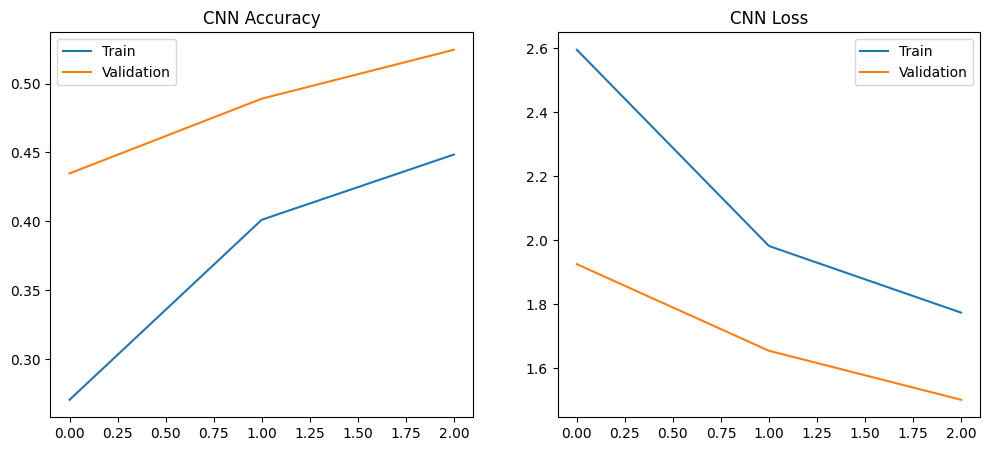

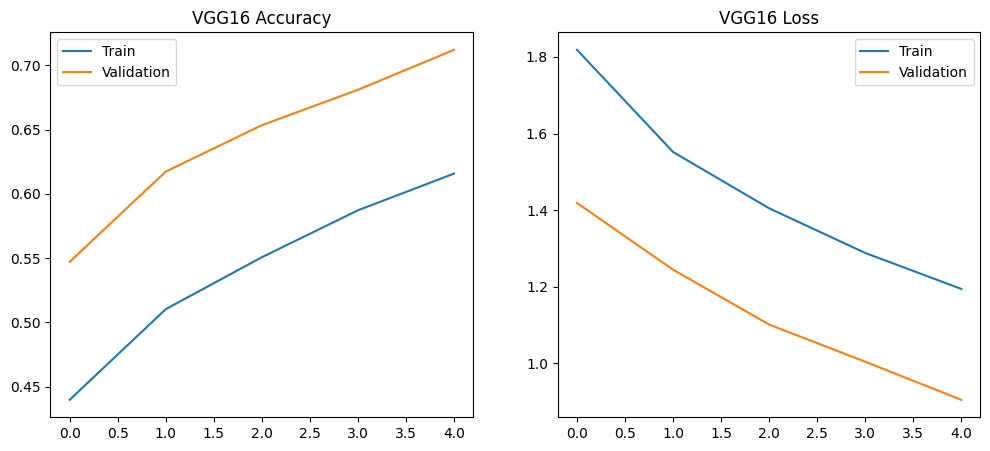

In [20]:
def plot_history(history,title):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(title+" Accuracy")

    plt.legend(["Train","Validation"])

    plt.subplot(1,2,2)

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(title+" Loss")

    plt.legend(["Train","Validation"])

    plt.show()

plot_history(history_cnn,"CNN")
plot_history(history_vgg_ft,"VGG16")

#Model Evaluation

In [21]:
def evaluate_model(model,name):

    predictions = model.predict(X_test)

    pred_labels = np.argmax(
        predictions,
        axis=1
    )

    acc = accuracy_score(
        y_test,
        pred_labels
    )

    precision = precision_score(
        y_test,
        pred_labels,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        pred_labels,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        pred_labels,
        average='weighted'
    )

    return [
        name,
        acc,
        precision,
        recall,
        f1
    ]

#Results

In [22]:
cnn_results = evaluate_model(
    cnn_model,
    "CNN"
)

vgg_results = evaluate_model(
    vgg16_model,
    "VGG16"
)

184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 338ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Accuracy Comparision

In [23]:
comparison = pd.DataFrame(

    [cnn_results,
     vgg_results],

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1
0,CNN,0.891533,0.902657,0.891533,0.890095
1,VGG16,0.709963,0.727066,0.709963,0.695731


#Model comparision

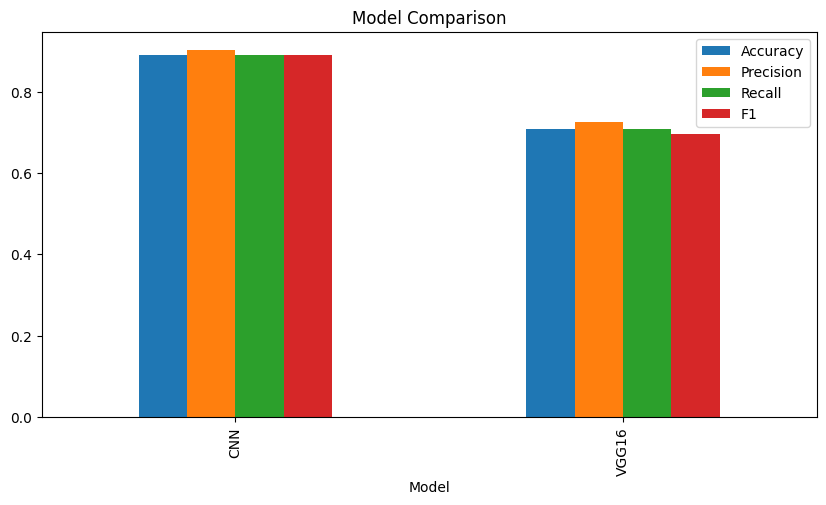

In [24]:
comparison.set_index(
    "Model"
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Model Comparison"
)

plt.show()

#Prediction

184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


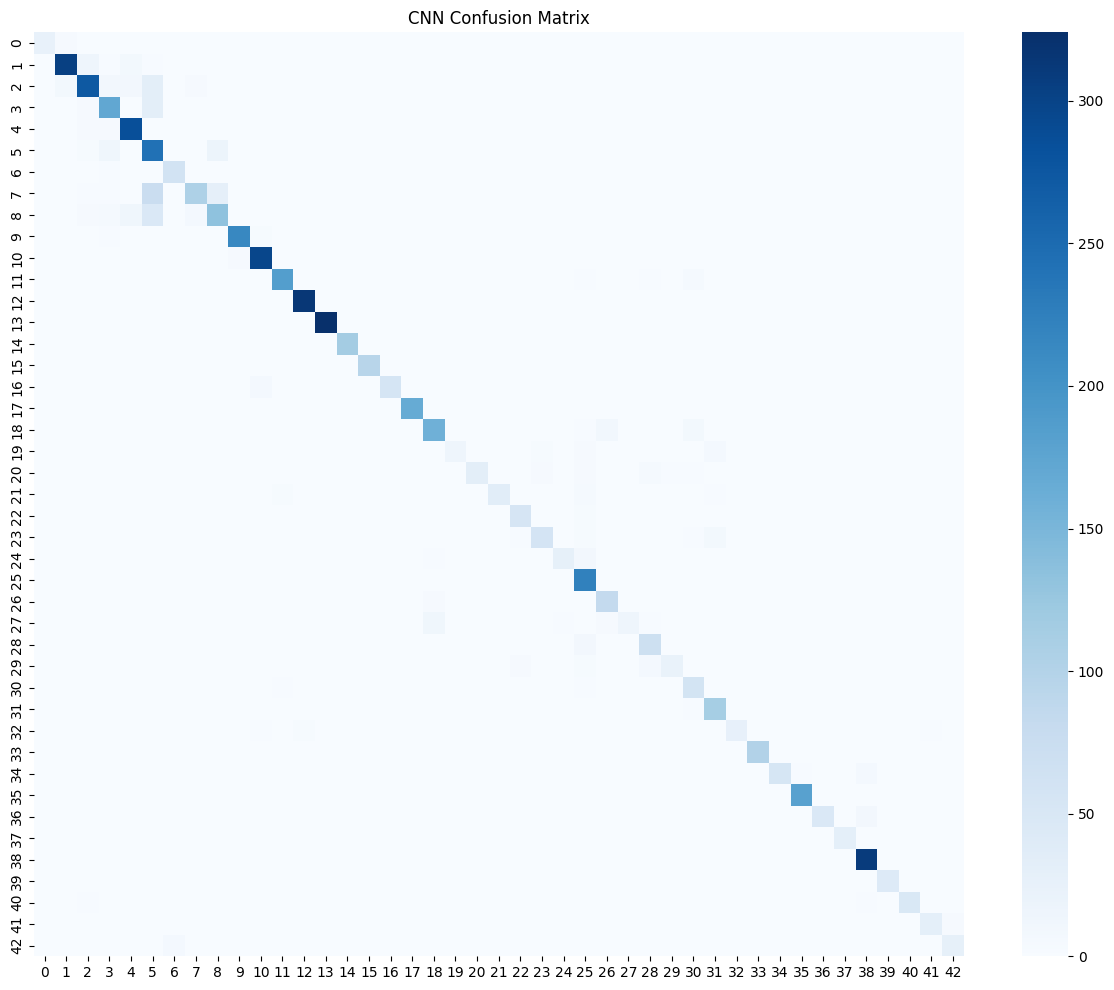

In [25]:
pred = np.argmax(
    cnn_model.predict(X_test),
    axis=1
)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

#classification report for CNN

In [26]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.81      0.89        31
           1       0.96      0.92      0.94       333
           2       0.88      0.81      0.84       338
           3       0.80      0.81      0.81       212
           4       0.90      0.96      0.93       297
           5       0.55      0.87      0.68       279
           6       0.90      0.97      0.93        63
           7       0.88      0.49      0.63       216
           8       0.72      0.63      0.68       212
           9       0.97      0.97      0.97       221
          10       0.95      0.98      0.97       302
          11       0.97      0.93      0.95       198
          12       0.98      1.00      0.99       315
          13       0.99      1.00      1.00       324
          14       1.00      0.99      1.00       117
          15       0.98      1.00      0.99        95
          16       1.00      0.89      0.94        63
          17       0.99    

#Actual Vs Prediction

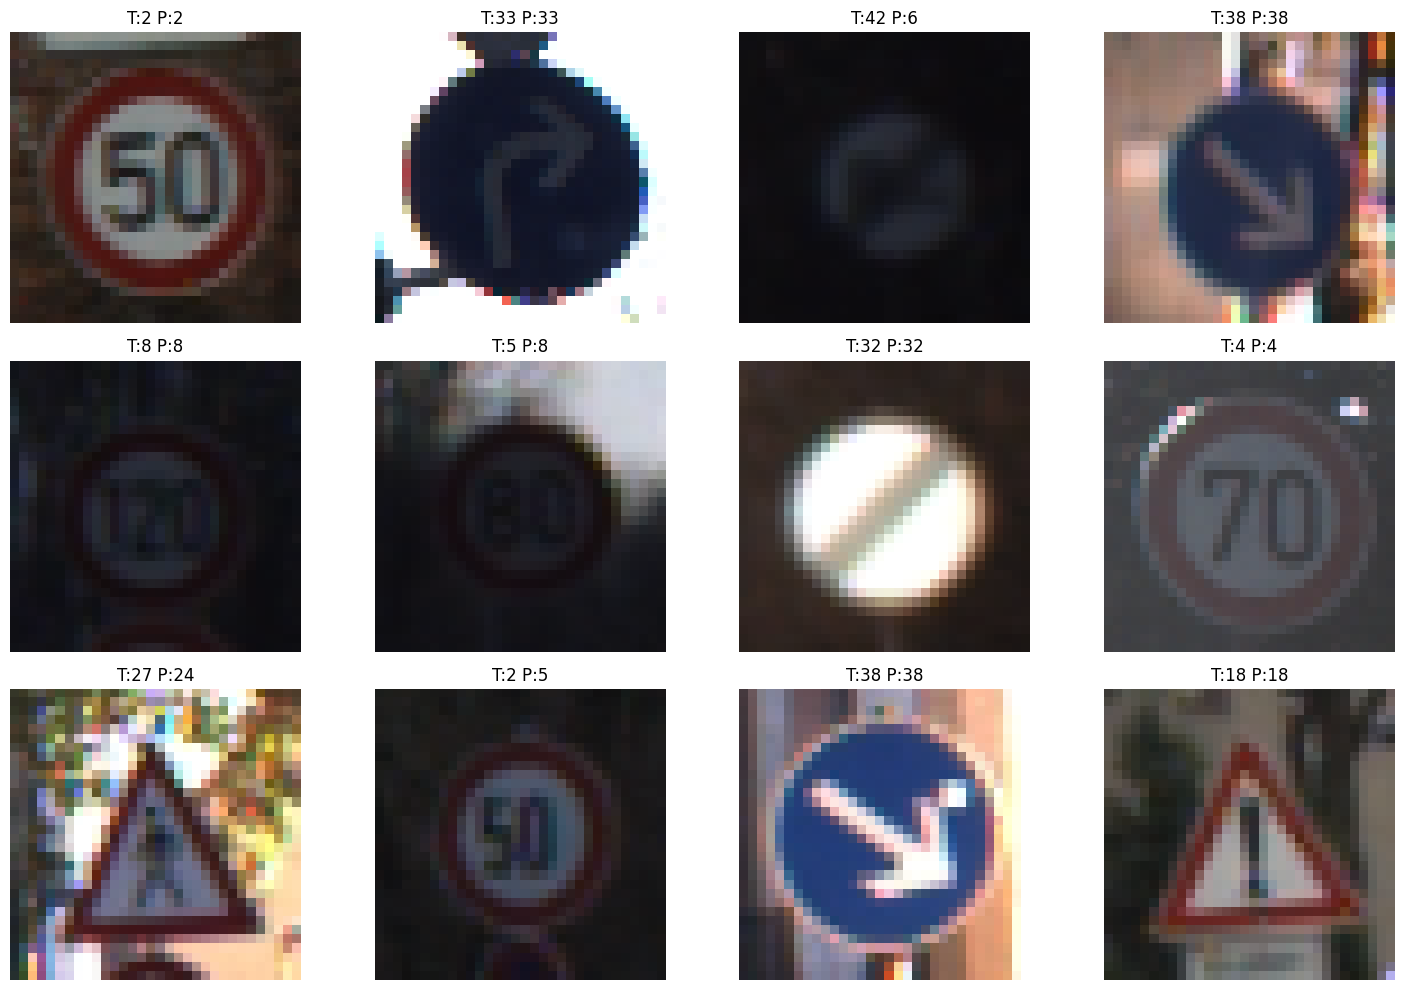

In [27]:
plt.figure(figsize=(15,10))

for i in range(12):

    idx = np.random.randint(
        len(X_test)
    )

    image = X_test[idx]

    prediction = np.argmax(
        cnn_model.predict(
            image.reshape(
                1,32,32,3
            ),
            verbose=0
        )
    )

    plt.subplot(3,4,i+1)

    plt.imshow(image)

    plt.title(
        f"T:{y_test[idx]} P:{prediction}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

#Parameters count

In [28]:
print("CNN Parameters")
print(cnn_model.count_params())

print("\nvgg16 Parameters")
print(vgg16_model.count_params())

CNN Parameters
81675

vgg16 Parameters
14785899
